In [11]:
import pandas as pd
import torch
import torch.nn as nn
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score, roc_auc_score
import time

In [5]:
# Load the dataset
dataset_path = 'Combined Data.csv'
data = pd.read_csv(dataset_path)
processed_data = data.dropna()
features = ['Time Stamp', 'A1 X-Axis', 'A1 Y-Axis', 'A1 Z-Axis', 'G1 X-Axis', 'G1 Y-Axis', 'G1 Z-Axis', 
            'A2 X-Axis', 'A2 Y-Axis', 'A2 Z-Axis', 'G2 X-Axis', 'G2 Y-Axis', 'G2 Z-Axis']
X = processed_data[features]
y = processed_data['ActivityLabel']

# Convert labels to integers
label_mapping = {label: idx for idx, label in enumerate(y.unique())}
y = y.map(label_mapping)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)


In [6]:
# Standardizing the features
scaler = StandardScaler()
print("Standardizing the features...")
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convert to PyTorch tensors
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32).to(device)
X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32).to(device)
y_train_tensor = torch.tensor(y_train.values, dtype=torch.long).to(device)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.long).to(device)

Standardizing the features...


In [3]:
scaler = StandardScaler()
print("Standardizing the features...")
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
start_time = time.time()

print("\nTraining the SVM model...")
svm_model = SVC(kernel='rbf', random_state=42, probability=True, verbose=True)
svm_model.fit(X_train_scaled, y_train)
fit_time = time.time() - start_time
print(f"\nModel training completed in {fit_time:.2f} seconds.")

print("\nMaking predictions on the test set...")
y_pred = svm_model.predict(X_test_scaled)
predict_time = time.time() - fit_time - start_time
print(f"Prediction completed in {predict_time:.2f} seconds.")
print("\nClassification Report:")
classification_report_result = classification_report(y_test, y_pred)
print(classification_report_result)
acc = accuracy_score(y_test, y_pred)
print(f"Accuracy: {acc:.4f}")
y_pred_proba = svm_model.predict_proba(X_test_scaled)[:, 1]
roc_auc_value = roc_auc_score(y_test, y_pred_proba)
print(f"ROC-AUC Score: {roc_auc_value:.4f}")
total_time = time.time() - start_time
print(f"\nTotal Execution Time: {total_time:.2f} seconds")

Standardizing the features...

Training the SVM model...
[LibSVM]
Model training completed in 2388.32 seconds.

Making predictions on the test set...
Prediction completed in 71.09 seconds.

Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.98      0.95     25564
           1       0.95      0.82      0.88     11261

    accuracy                           0.93     36825
   macro avg       0.94      0.90      0.92     36825
weighted avg       0.93      0.93      0.93     36825

Accuracy: 0.9310
ROC-AUC Score: 0.9546

Total Execution Time: 2530.20 seconds


In [7]:
class SVMModel(nn.Module):
    def __init__(self, input_dim, num_classes):
        super(SVMModel, self).__init__()
        self.fc = nn.Linear(input_dim, num_classes)

    def forward(self, x):
        return self.fc(x)

# Model initialization
input_dim = X_train_tensor.shape[1]
num_classes = len(label_mapping)
model = SVMModel(input_dim, num_classes).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

In [8]:
# Training the model
print("Training the model on GPU...")
start_time = time.time()
num_epochs = 10
batch_size = 64

for epoch in range(num_epochs):
    model.train()
    for i in range(0, len(X_train_tensor), batch_size):
        X_batch = X_train_tensor[i:i+batch_size]
        y_batch = y_train_tensor[i:i+batch_size]

        # Forward pass
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)

        # Backward pass and optimization
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {loss.item():.4f}")

fit_time = time.time() - start_time
print(f"Model training completed in {fit_time:.2f} seconds.")

Training the model on GPU...
Epoch [1/10], Loss: 0.1988
Epoch [2/10], Loss: 0.1986
Epoch [3/10], Loss: 0.1986
Epoch [4/10], Loss: 0.1986
Epoch [5/10], Loss: 0.1986
Epoch [6/10], Loss: 0.1986
Epoch [7/10], Loss: 0.1986
Epoch [8/10], Loss: 0.1986
Epoch [9/10], Loss: 0.1986
Epoch [10/10], Loss: 0.1986
Model training completed in 15.25 seconds.


In [17]:
# %%
# Evaluate the model
print("\nEvaluating the model on GPU...")
model.eval()
with torch.no_grad():
    y_pred_probs = model(X_test_tensor)  # Logits
    y_pred = torch.argmax(y_pred_probs, axis=1)  # Predicted labels

# Convert predictions and labels back to CPU
y_pred = y_pred.cpu().numpy()
y_test = y_test_tensor.cpu().numpy()

# Prepare target names
target_names = [str(label) for label in label_mapping.keys()]

print("\nClassification Report:")
classification_report_result = classification_report(y_test, y_pred, target_names=target_names)
print(classification_report_result)

# Compute accuracy
acc = accuracy_score(y_test, y_pred)
print(f"Accuracy: {acc:.4f}")

# Compute ROC AUC score for multi-class
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_auc_score

classes = list(label_mapping.values())
y_test_binarized = label_binarize(y_test, classes=classes)
y_pred_proba = torch.softmax(y_pred_probs, dim=1).cpu().numpy()

# Compute ROC AUC score manually for each class
# roc_auc_scores = []
# for i in range(len(classes)):
#     roc_auc = roc_auc_score(y_test_binarized[:, i], y_pred_proba[:, i])
#     roc_auc_scores.append(roc_auc)

# # Compute macro-average ROC AUC
# roc_auc_value = sum(roc_auc_scores) / len(roc_auc_scores)
# print(f"ROC-AUC Score (macro-average): {roc_auc_value:.4f}")

total_time = time.time() - start_time
print(f"\nTotal Execution Time: {total_time:.2f} seconds")



Evaluating the model on GPU...

Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.92      0.91     25564
           1       0.81      0.74      0.77     11261

    accuracy                           0.87     36825
   macro avg       0.85      0.83      0.84     36825
weighted avg       0.86      0.87      0.87     36825

Accuracy: 0.8667

Total Execution Time: 432.12 seconds


In [18]:
torch.save(model.state_dict(), 'svm_model_gpu.pth')
print("Model saved as 'svm_model_gpu.pth'")

Model saved as 'svm_model_gpu.pth'


In [22]:
import joblib

joblib.dump(model, 'SVM.pkl')

['SVM.pkl']


Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.68      0.78       225
           1       0.00      0.00      0.00        12

    accuracy                           0.65       237
   macro avg       0.46      0.34      0.39       237
weighted avg       0.88      0.65      0.74       237


Thresholded Predictions:
              precision    recall  f1-score   support

           0       0.93      0.68      0.78       225
           1       0.00      0.00      0.00        12

    accuracy                           0.65       237
   macro avg       0.46      0.34      0.39       237
weighted avg       0.88      0.65      0.74       237



C:\Users\Leonm\AppData\Local\Temp\ipykernel_20368\1488073347.py:26: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load('svm_model_gpu.pth', map_location=d

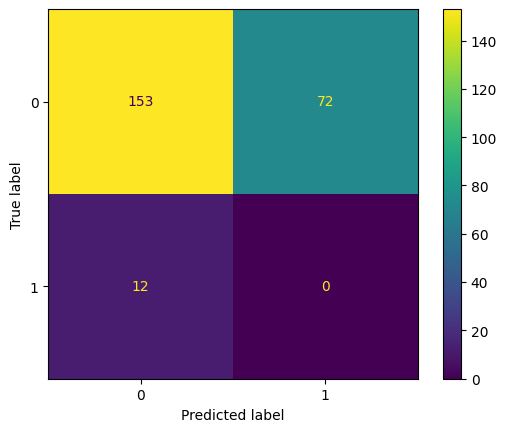

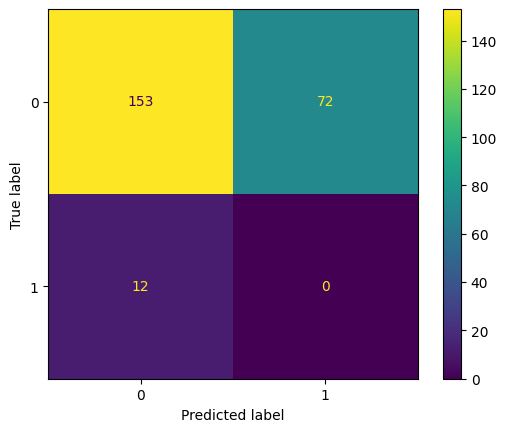

In [31]:
import pandas as pd
import numpy as np
import torch
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
from sklearn.preprocessing import label_binarize

# Define the SVM model architecture
class SVMModel(torch.nn.Module):
    def __init__(self, input_dim, num_classes):
        super(SVMModel, self).__init__()
        self.fc = torch.nn.Linear(input_dim, num_classes)

    def forward(self, x):
        return self.fc(x)

# Load the saved state dictionary
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Define the model structure (ensure input_dim and num_classes match your training setup)
input_dim = 13  # Number of features (excluding timestamp)
num_classes = 2  # Update based on your classification task
svm_model = SVMModel(input_dim=input_dim, num_classes=num_classes).to(device)

# Load the state dictionary into the model
state_dict = torch.load('svm_model_gpu.pth', map_location=device)
svm_model.load_state_dict(state_dict)
svm_model.eval()  # Set the model to evaluation mode

# Load the new test dataset
new_data_path = 'Test.csv'
new_data = pd.read_csv(new_data_path)
new_data = new_data.dropna()

# Define features and labels
features = ['Time Stamp', 'A1 X-Axis', 'A1 Y-Axis', 'A1 Z-Axis', 'G1 X-Axis',
            'G1 Y-Axis', 'G1 Z-Axis', 'A2 X-Axis', 'A2 Y-Axis', 'A2 Z-Axis',
            'G2 X-Axis', 'G2 Y-Axis', 'G2 Z-Axis']
X_new = new_data[features]
y_true_classes_new = new_data['ActivityLabel']

# Map labels to integers (ensure consistent mapping)
label_mapping = {label: idx for idx, label in enumerate(y_true_classes_new.unique())}
y_true_classes_new = y_true_classes_new.map(label_mapping)

# Preprocess data
scaler = StandardScaler()
X_new_scaled = scaler.fit_transform(X_new)  # Ensure scaling matches training
X_new_tensor = torch.tensor(X_new_scaled, dtype=torch.float32).to(device)

# Predict with the PyTorch model
with torch.no_grad():
    y_pred_logits = svm_model(X_new_tensor)
    y_pred_probs = torch.softmax(y_pred_logits, dim=1)
    y_pred_classes_new = torch.argmax(y_pred_probs, axis=1).cpu().numpy()

# Classification Report
print("\nClassification Report:")
print(classification_report(y_true_classes_new, y_pred_classes_new))

# Confusion Matrix Display
ConfusionMatrixDisplay.from_predictions(y_true_classes_new, y_pred_classes_new)

# Optional: Apply thresholding for binary classification
if y_pred_probs.shape[1] == 2:  # Binary classification
    threshold = 0.5
    y_pred_classes_new_with_threshold = (y_pred_probs[:, 1] > threshold).cpu().numpy().astype(int)
    print("\nThresholded Predictions:")
    print(classification_report(y_true_classes_new, y_pred_classes_new_with_threshold))
    ConfusionMatrixDisplay.from_predictions(y_true_classes_new, y_pred_classes_new_with_threshold)
